# 12 - Dataset v5 Label Decimation Correction

## Research question

Why was the corrected v5 dataset needed before making final architectural claims?

## Artifact paths loaded

- `results/v5/dataset_variant_comparison.csv`
- `results/v5/dataset_variant_comparison.json`
- `reports/v5_campaign/phase1_dataset_v5_report.md`
- `results/v5/figures/soc_initial_bias_by_temperature.png`
- `results/v5/figures/routing_conflict_by_decimation_mode.png`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/dataset_variant_comparison.csv',
    'results/v5/dataset_variant_comparison.json',
    'reports/v5_campaign/phase1_dataset_v5_report.md',
    'results/v5/figures/soc_initial_bias_by_temperature.png',
    'results/v5/figures/routing_conflict_by_decimation_mode.png',
]
show_artifact_status(ARTIFACTS)

variant_df = read_csv_safe("results/v5/dataset_variant_comparison.csv")
variant_json = read_json_safe("results/v5/dataset_variant_comparison.json")
detail = variant_json.get("detail", {}) if isinstance(variant_json, dict) else {}


,artifact,exists,bytes
0,results/v5/dataset_variant_comparison.csv,True,742
1,results/v5/dataset_variant_comparison.json,True,21460
2,reports/v5_campaign/phase1_dataset_v5_report.md,True,3512
3,results/v5/figures/soc_initial_bias_by_tempera...,True,36281
4,results/v5/figures/routing_conflict_by_decimat...,True,31997


In [3]:
if not variant_df.empty:
    cols = ["variant","scenario","label_mode","decimation_mode","segments","train_windows","val_windows","test_windows","label_shift_vs_v4_mean_pct","label_shift_vs_v4_max_pct","leakage_overlaps"]
    display(variant_df[cols].sort_values(["scenario", "variant"]).round(4))
else:
    display(Markdown("Dataset variant table unavailable."))


,variant,scenario,label_mode,decimation_mode,segments,train_windows,val_windows,test_windows,label_shift_vs_v4_mean_pct,label_shift_vs_v4_max_pct,leakage_overlaps
0,v4,A,legacy,first_sample,103,15641,9084,18914,0.0000,0.0000,0
2,v5a,A,ohmic_corrected,first_sample,103,15641,9084,18914,3.5317,93.5793,0
4,v5b,A,legacy,mean_per_second,103,15641,9084,18914,1.0919,12.5464,0
6,v5c,A,ohmic_corrected,mean_per_second,103,15641,9084,18914,1.3472,16.2429,0
1,v4,B,legacy,first_sample,103,30457,3538,8010,0.0000,0.0000,0
3,v5a,B,ohmic_corrected,first_sample,103,30457,3538,8010,1.0881,38.0451,0
5,v5b,B,legacy,mean_per_second,103,30457,3538,8010,0.8068,12.4754,0
7,v5c,B,ohmic_corrected,mean_per_second,103,30457,3538,8010,0.6839,16.2425,0


In [4]:
phase1 = artifact("reports/v5_campaign/phase1_dataset_v5_report.md")
if phase1.exists():
    text = phase1.read_text(encoding="utf-8", errors="replace")
    m = re.search(r"only\s+(\d+)\s*/\s*(\d+)\s+segments start at rest", text, flags=re.I)
    if m:
        rest = int(m.group(1)); total = int(m.group(2)); load = total - rest
        display(pd.DataFrame([
            {"segment_start_state": "rest_start", "segments": rest, "pct": 100*rest/total},
            {"segment_start_state": "load_start", "segments": load, "pct": 100*load/total},
        ]).round(2))
    else:
        display(Markdown("Phase 1 report present, but rest-start regex was not found."))
else:
    display(Markdown("Phase 1 report missing; segment-start summary skipped."))


,segment_start_state,segments,pct
0,rest_start,55,53.4
1,load_start,48,46.6


In [5]:
rows = []
for key, payload in detail.items():
    if not isinstance(payload, dict) or not key.startswith(("v4_", "v5")):
        continue
    for split, by_temp in payload.get("metadata", {}).get("split_window_counts", {}).items():
        for temp, n in by_temp.items():
            rows.append({"variant_scenario": key, "split": split, "temperature": temp, "windows": n})
split_df = pd.DataFrame(rows)
if not split_df.empty:
    display(split_df.pivot_table(index=["variant_scenario","split"], columns="temperature", values="windows", aggfunc="sum", fill_value=0).astype(int))
else:
    display(Markdown("No split composition embedded in dataset JSON."))


temperature             0degC  10degC  25degC  40degC  n10degC  n20degC
variant_scenario split                                                 
v4_scenario_A    test       0       0       0    6148     7387     5379
                 train      0    7442    8199       0        0        0
                 val     7619     675     790       0        0        0
v4_scenario_B    test    1395    1520    1712    1079     1342      962
                 train   5286    5750    6346    4245     5107     3723
                 val      618     674     789     448      597      412
v5a_scenario_A   test       0       0       0    6148     7387     5379
                 train      0    7442    8199       0        0        0
                 val     7619     675     790       0        0        0
v5a_scenario_B   test    1395    1520    1712    1079     1342      962
                 train   5286    5750    6346    4245     5107     3723
                 val      618     674     789     448      597      412
v5b_scenario_A   test       0       0       0    6148     7387     5379
                 train      0    7442    8199       0        0        0
                 val     7619     675     790       0        0        0
v5b_scenario_B   test    1395    1520    1712    1079     1342      962
                 train   5286    5750    6346    4245     5107     3723
                 val      618     674     789     448      597      412
v5c_scenario_A   test       0       0       0    6148     7387     5379
                 train      0    7442    8199       0        0        0
                 val     7619     675     790       0        0        0
v5c_scenario_B   test    1395    1520    1712    1079     1342      962
                 train   5286    5750    6346    4245     5107     3723
                 val      618     674     789     448      597      412

,variant_scenario,temperature,soc_initial_mean,soc_initial_min,soc_initial_max
0,v4_scenario_A,0degC,0.8041,0.1119,0.9997
1,v4_scenario_A,10degC,0.7320,0.1281,0.9993
2,v4_scenario_A,25degC,0.9224,0.5416,1.0000
3,v4_scenario_A,40degC,0.8025,0.1405,1.0000
4,v4_scenario_A,n10degC,0.8663,0.1490,0.9999
5,v4_scenario_A,n20degC,0.8625,0.1028,0.9993
6,v4_scenario_B,0degC,0.8041,0.1119,0.9997
7,v4_scenario_B,10degC,0.7320,0.1281,0.9993
8,v4_scenario_B,25degC,0.9224,0.5416,1.0000
9,v4_scenario_B,40degC,0.8025,0.1405,1.0000


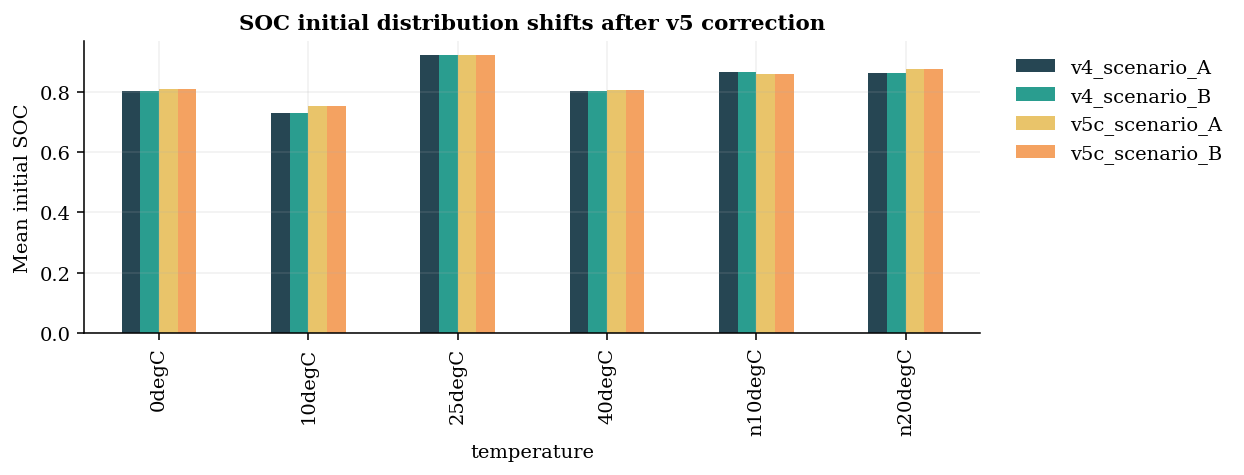

In [6]:
rows = []
for key, payload in detail.items():
    if not isinstance(payload, dict) or not key.startswith(("v4_", "v5c_")):
        continue
    for temp, stats in payload.get("soc_initial_stats", {}).items():
        rows.append({"variant_scenario": key, "temperature": temp, "soc_initial_mean": stats.get("mean"), "soc_initial_min": stats.get("min"), "soc_initial_max": stats.get("max")})
bias_df = pd.DataFrame(rows)
if not bias_df.empty:
    display(bias_df.round(4))
    ax = bias_df.pivot(index="temperature", columns="variant_scenario", values="soc_initial_mean").plot(kind="bar", figsize=(9, 3.5), color=COLORS)
    ax.set_ylabel("Mean initial SOC")
    ax.set_title("SOC initial distribution shifts after v5 correction")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout(); plt.show()
else:
    maybe_display_png("results/v5/figures/soc_initial_bias_by_temperature.png")


,decimation_mode,sign_conflict_pct_mean,envelope_exceeded_pct_mean,justification
0,first_sample,2.482,9.247,NaN
1,mean_per_second,0.000,0.000,kept current equals the intra-second mean by c...


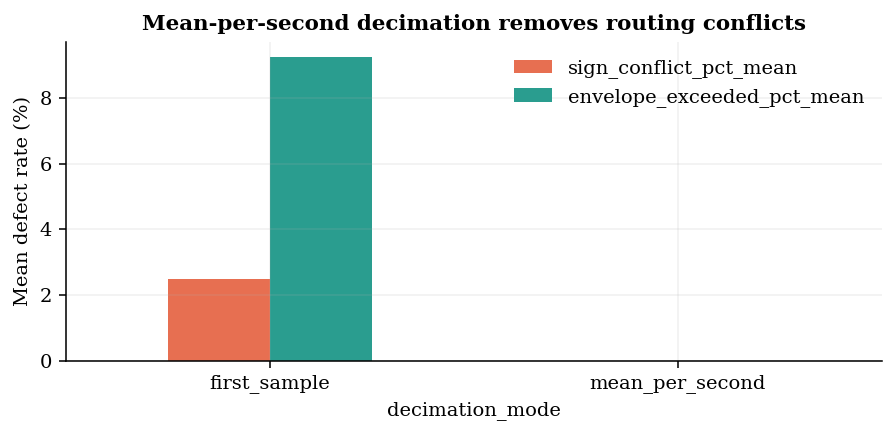

**Artifact note:** no field named `envelope_unsatisfiable_pct_mean` exists. Using `envelope_exceeded_pct_mean` as the available proxy.

In [7]:
defects = detail.get("decimation_defect_rates", {}) if isinstance(detail, dict) else {}
defect_df = pd.DataFrame([{"decimation_mode": k, **v} for k, v in defects.items()])
if not defect_df.empty:
    display(defect_df)
    cols = [c for c in ["sign_conflict_pct_mean", "envelope_exceeded_pct_mean"] if c in defect_df.columns]
    ax = defect_df.set_index("decimation_mode")[cols].plot(kind="bar", figsize=(6.5, 3.2), color=[OUR_COLOR, COLORS[1]])
    ax.set_ylabel("Mean defect rate (%)")
    ax.set_title("Mean-per-second decimation removes routing conflicts")
    plt.xticks(rotation=0); plt.tight_layout(); plt.show()
else:
    maybe_display_png("results/v5/figures/routing_conflict_by_decimation_mode.png")
if "envelope_unsatisfiable_pct_mean" not in defect_df.columns:
    display(Markdown("**Artifact note:** no field named `envelope_unsatisfiable_pct_mean` exists. Using `envelope_exceeded_pct_mean` as the available proxy."))


## Interpretation

v5c fixes two upstream confounders: Ohmic-corrected labels and mean-per-second decimation. First-sample decimation had nonzero sign conflicts and envelope-exceeded seconds; mean-per-second decimation removes both by construction.

## Reviewer-risk note

Do not claim v5 makes labels physically perfect. It removes identified v4 artifacts; polarization and OCV observability remain limitations.

## Final conclusion

v5 separates true model behavior from v4 label/decimation artifacts.


In [8]:
show_missing()


### Missing artifacts recorded by this notebook: none

## Publication asset export (PUBLICATION_ASSET_EXPORT_V1)

This cell exports manuscript-ready figures/tables from existing v5 CSV/JSON artifacts only. It does not run training or alter experiment results.


In [9]:
# PUBLICATION_ASSET_EXPORT_V1
from pathlib import Path
import sys
EXPORT_DIR = Path('notebooks/ablation_studies_v5_final').resolve()
if str(EXPORT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPORT_DIR))
from publication_asset_exports import export_for_notebook
validation = export_for_notebook('12')
print('publication assets refreshed:', validation['png_present'], 'figures and', validation['csv_present'], 'tables')


publication assets refreshed: 7 figures and 7 tables
